<a href="https://colab.research.google.com/github/zero3791/projekt-1-slave-trade/blob/main/01_Analiza_%C5%9Bmiertelno%C5%9Bci_w_handlu_niewolnikami.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Logistyka Cierpienia: Analiza śmiertelności w Transatlantyckim Handlu Niewolnikami.

Cel: Stworzenie interaktywnego raportu, który opowiada tę tragiczną historię liczbami.
Etapy:
- Wyczyszczenie danych (daty, trasy, brakujące liczby).

- Analiza statystyczna: Jak czas trwania podróży, port wypłynięcia i zagęszczenie (liczba osób/m2) wpływały na % śmiertelności?

- Wizualizacja tras na mapie (GeoPandas).

Zbiór danych trans-atlantic.csv pochodzi ze strony slavevoyages.org.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, LineString

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projekt-1-slave-trade/data/raw/trans-atlantic.csv')

/tmp/ipython-input-956318524.py:1: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projekt-1-slave-trade/data/raw/trans-atlantic.csv')


In [ ]:
df.head()

,Voyage ID,Year arrived with captives,Total disembarked (IMP),Total embarked (IMP),Duration of captives' crossing (in days),"Voyage duration, homeport to disembarkation (in days)",Crew at first landing of captives,Crew at voyage outset,Standardized Tonnage (IMP),Sterling cash price in Jamaica (IMP),...,voyage_itinerary__imp_principal_region_slave_dis__name,voyage_itinerary__imp_principal_region_of_slave_purchase__name,voyage_itinerary__imp_port_voyage_begin__name,voyage_itinerary__imp_principal_port_slave_dis__name,voyage_itinerary__imp_principal_place_of_slave_purchase__name,voyage_sources,enslavers,Deceased Captives,Mortality Rate,Density
0,1,1817.0,290.0,404.0,56.0,165.0,0.0,0.0,0.0,0.0,...,Bahia,East Africa and Indian Ocean islands,Rio de Janeiro,"Bahia, place unspecified",Mozambique,"“Conselho Ultramarino.” Lisboa, PT, n.d. Arq...","Captain: Dias, Manoel Jose",114.0,28.217822,0.0
1,2,1817.0,223.0,246.0,74.0,190.0,0.0,30.0,0.0,0.0,...,Bahia,East Africa and Indian Ocean islands,"Bahia, place unspecified","Bahia, place unspecified",Mozambique,"Great Britain, Parliamentary Papers: 1777, ...","Investor: Chaves, Domingos Pires dos Santos|Ca...",23.0,9.349593,0.0
2,3,1817.0,350.0,405.0,0.0,120.0,0.0,28.0,0.0,0.0,...,Bahia,West Central Africa and St Helena,"Bahia, place unspecified","Bahia, place unspecified",Cabinda,"Great Britain, Parliamentary Papers: 1777, ...","Investor: Gomes, Antonio Jose|Captain: Ferreir...",55.0,13.580247,0.0
3,4,1817.0,342.0,381.0,0.0,236.0,0.0,0.0,0.0,0.0,...,Bahia,East Africa and Indian Ocean islands,"Bahia, place unspecified","Bahia, place unspecified",Quilimane,"“Conselho Ultramarino.” Lisboa, PT, n.d. Arq...","Investor: Ferreira, Miguel Gonçalves|Captain: ...",39.0,10.236220,0.0
4,5,1817.0,516.0,578.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Bahia,West Central Africa and St Helena,"Bahia, place unspecified","Bahia, place unspecified",Cabinda,"Great Britain, Parliamentary Papers: 1777, ...","Investor: Rodrigues, Jose Antonio",62.0,10.726644,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36344 entries, 0 to 36343
Data columns (total 45 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Voyage ID                                                       36342 non-null  object 
 1   Year arrived with captives                                      36342 non-null  object 
 2   Total disembarked (IMP)                                         36340 non-null  float64
 3   Total embarked (IMP)                                            36340 non-null  float64
 4   Duration of captives' crossing (in days)                        36340 non-null  float64
 5   Voyage duration, homeport to disembarkation (in days)           36340 non-null  float64
 6   Crew at first landing of captives                               36340 non-null  float64
 7   Crew at voyage outset                            

Podstawowe statystyki:

In [ ]:
df.describe()

,Total disembarked (IMP),Total embarked (IMP),Duration of captives' crossing (in days),"Voyage duration, homeport to disembarkation (in days)",Crew at first landing of captives,Crew at voyage outset,Standardized Tonnage (IMP),Sterling cash price in Jamaica (IMP),Percentage of captives who died during crossing (IMP),Percent women,...,Month vessel departed Africa,Month voyage began,Month first disembarkation of captives,Percent girls,Percent children,Percent women.1,Month departed last place of landing,Outcome of voyage for investors,Percent male,Percent female
count,36340.000000,36340.000000,36340.000000,36340.000000,36340.000000,36340.000000,36340.000000,36340.000000,36340.000000,36340.000000,...,36340.000000,36340.000000,36340.000000,36340.000000,36340.000000,36340.000000,36340.000000,36340.0,36340.000000,36340.000000
mean,253.049670,292.887122,5.919207,109.224876,1.453027,10.588773,89.403035,0.954892,0.025041,0.006948,...,1.384095,4.470143,3.838663,0.008736,0.025029,0.025278,0.985443,0.0,0.070342,0.038573
std,147.195838,164.893102,19.124312,163.887389,6.208701,17.194010,117.497936,6.689413,0.534096,0.046912,...,3.122215,4.161079,4.162318,0.035639,0.089687,0.086138,2.595199,0.0,0.205214,0.117486
min,0.000000,0.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,150.000000,179.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
50%,246.000000,284.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
75%,340.000000,386.000000,0.000000,230.000000,0.000000,21.000000,170.000000,0.000000,0.000000,0.000000,...,0.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
max,1700.000000,2024.000000,310.000000,3164.000000,90.000000,606.000000,1269.200000,101.150000,100.000000,0.988100,...,12.000000,12.000000,12.000000,0.629032,1.000000,1.000000,12.000000,0.0,1.000000,1.000000


##Analiza wyników:
Rozmiar danych: Mamy 36 344 rekordy. To ogromna liczba rejsów. To uświadamia skalę procederu.

Jakość danych (IMP): kluczowe kolumny jak Total disembarked (IMP) mają bardzo mało braków danych (tylko 4 braki!). Skrót IMP oznacza Imputed (wypełnione/szacowane). Historycy wykonali tytaniczną pracę, estymując te liczby na podstawie dokumentów przewozowych, ubezpieczeń itp., tam gdzie brakowało bezpośrednich zapisów.

**Problematyczne typy danych:**

Year arrived with captives jest typu object (tekst). To czerwona flaga. Komputer nie zrozumie, że "1750" to liczba, jeśli będzie myślał, że to tekst. Prawdopodobnie są tam jakieś znaki specjalne lub błędy.

Daty w formacie "Month..." są jako float64. To też sugeruje, że będziemy musieli je skleić, jeśli zechcemy analizować sezonowość.

Braki (NaN): Kolumny geograficzne (od 37 w dół), np. voyage_itinerary__region_of_return__name, mają dużo braków (tylko 10k wypełnionych). To logiczne – wiemy skąd statek wypłynął i dokąd wiózł ludzi, ale często nie wiemy, gdzie wrócił (lub zatonął/został sprzedany).

Czyszczenie danych

In [ ]:
# KROK 1: CZYSZCZENIE DANYCH
# Tworzymy kopię, aby nie pracować na oryginale
df_clean = df.copy()

# Usuwamy wiersze, gdzie kluczowe dane są puste (te 4 brakujące wiersze)
# Skupiamy się na kolumnie 'Year arrived with captives' jako wyznaczniku poprawności wiersza
df_clean = df_clean.dropna(subset=['Year arrived with captives'])

# Konwertujemy rok na liczbę całkowitą (jest obiektem/tekstem, chcemy liczbę)
# Używamy errors='coerce', co zamieni błędne wartości na NaN, a potem je usuwamy
df_clean['Year arrived with captives'] = pd.to_numeric(df_clean['Year arrived with captives'], errors='coerce')
df_clean = df_clean.dropna(subset=['Year arrived with captives'])
df_clean['Year arrived with captives'] = df_clean['Year arrived with captives'].astype(int)

# ---

# KROK 2: INŻYNIERIA CECH (Tworzenie nowych zmiennych)

# A. Obliczamy liczbę zmarłych (Zaokrętowani - Wyokrętowani)
df_clean['Deaths'] = df_clean['Total embarked (IMP)'] - df_clean['Total disembarked (IMP)']

# B. Obliczamy % śmiertelności
df_clean['Mortality Rate'] = (df_clean['Deaths'] / df_clean['Total embarked (IMP)']) * 100

# C. Obliczamy zagęszczenie (Liczba niewolników na jednostkę tonażu)
# Uwaga: Tonaż (Standardized Tonnage) to miara objętości statku, nie wagi.
df_clean['Density'] = df_clean['Total embarked (IMP)'] / df_clean['Standardized Tonnage (IMP)']

# D. Tworzymy Dekadę (np. 1783 -> 1780)
# Dzielimy całkowicie przez 10 i mnożymy przez 10
df_clean['Decade'] = (df_clean['Year arrived with captives'] // 10) * 10

# ---

# SPRAWDZENIE WYNIKÓW
print(f"Liczba wierszy po czyszczeniu: {len(df_clean)}")
print("\n--- Przykładowe nowe kolumny ---")
display(df_clean[['Year arrived with captives', 'Decade', 'Total embarked (IMP)', 'Deaths', 'Mortality Rate', 'Density']].head())

print("\n--- Statystyki opisowe dla nowych cech ---")
# Metoda describe() pokaże nam średnią, minimum, maksimum etc.
display(df_clean[['Mortality Rate', 'Density']].describe())

Liczba wierszy po czyszczeniu: 36340

--- Przykładowe nowe kolumny ---


,Year arrived with captives,Decade,Total embarked (IMP),Deaths,Mortality Rate,Density
0,1817,1810,404.0,114.0,28.217822,inf
1,1817,1810,246.0,23.0,9.349593,inf
2,1817,1810,405.0,55.0,13.580247,inf
3,1817,1810,381.0,39.0,10.236220,inf
4,1817,1810,578.0,62.0,10.726644,inf



--- Statystyki opisowe dla nowych cech ---


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,Mortality Rate,Density
count,3.470700e+04,3.590300e+04
mean,-inf,inf
std,NaN,NaN
min,-inf,0.000000e+00
25%,8.635097e+00,1.506715e+00
50%,1.153846e+01,NaN
75%,1.702128e+01,NaN
max,1.000000e+02,inf


##Analiza wyników:


---


mean: -inf (Mortality Rate): Minus nieskończoność? To niemożliwe. Śmiertelność nie może być ujemna (chyba że ludzie rodzili się masowo na pokładzie i liczono ich jako "zysk", ale tu badamy zgony). To oznacza, że w niektórych wierszach Deaths jest ujemne (czyli Total disembarked > Total embarked).

max: inf (Density): Nieskończone zagęszczenie. Matematycznie oznacza to dzielenie przez zero. Wzór: $Density = \frac{Embarkded}{Tonnage}$.

Wniosek: Niektóre statki mają wpisany Tonnage = 0 lub brak danych (NaN zamieniony na 0).

##Doczyszczanie Danych (Sanity Check)
Zasady do wdrożenia:

Tonaż > 0: Statek musi mieć objętość.

Liczba zaokrętowanych > 0: Nie badamy pustych rejsów.

Śmiertelność pomiędzy 0% a 100%: Nie można umrzeć "ujemnie" ani w 110%.

In [ ]:
print(f"Liczba wierszy przed filtrowaniem: {len(df_clean)}")

# 1. Usuwamy rejsy z zerowym lub ujemnym tonażem (powoduje inf w Density)
df_clean = df_clean[df_clean['Standardized Tonnage (IMP)'] > 0]

# 2. Usuwamy rejsy, gdzie nikt nie wszedł na pokład (powoduje błędy w Mortality)
df_clean = df_clean[df_clean['Total embarked (IMP)'] > 0]

# 3. Usuwamy anomalie w śmiertelności (ujemna lub > 100%)
# To eliminuje przypadki, gdzie więcej osób wysiadło niż wsiadło (błędy w zapisach historycznych)
df_clean = df_clean[df_clean['Mortality Rate'].between(0, 100)]

# --- PONOWNE SPRAWDZENIE ---
print(f"Liczba wierszy po filtrowaniu: {len(df_clean)}")

print("\n--- Poprawione statystyki ---")
desc = df_clean[['Mortality Rate', 'Density', 'Duration of captives\' crossing (in days)']].describe()
display(desc)

Liczba wierszy przed filtrowaniem: 36340
Liczba wierszy po filtrowaniu: 15426

--- Poprawione statystyki ---


,Mortality Rate,Density,Duration of captives' crossing (in days)
count,15426.000000,15426.000000,15426.000000
mean,14.454340,1.720708,5.676650
std,12.029223,1.033826,20.947026
min,0.000000,0.004167,0.000000
25%,8.635097,1.127820,0.000000
50%,11.839420,1.513988,0.000000
75%,18.253214,2.015280,0.000000
max,100.000000,19.375000,310.000000


##Analiza wyników:


---


**Średnia śmiertelność (Mean): 14.45%.**

To przerażająca statystyka. Oznacza to, że statystycznie co siódma osoba wchodząca na statek nie docierała do lądu. To nie były "wypadki", to była systemowa cecha tego transportu.

**Maksimum (Max): 100%.**

Były rejsy, z których nikt nie ocalał. Puste statki (tzw. ghost ships) lub katastrofy.

**Czas trwania (Duration) - UWAGA!**

Maksimum to 310 dni.

ALE mamy problem: Spójrz na medianę (50%). Wynosi 0.000000. To niemożliwe, żeby połowa statków teleportowała się z Afryki do Ameryki.

Wniosek: Wiele rekordów ma wpisane "0" w czasie trwania, co w tym zbiorze oznacza brak danych.

##Analiza statystyczna i Wizualizacja

Macierz korelacji

Liczba wierszy do analizy czasu i śmiertelności: 1380


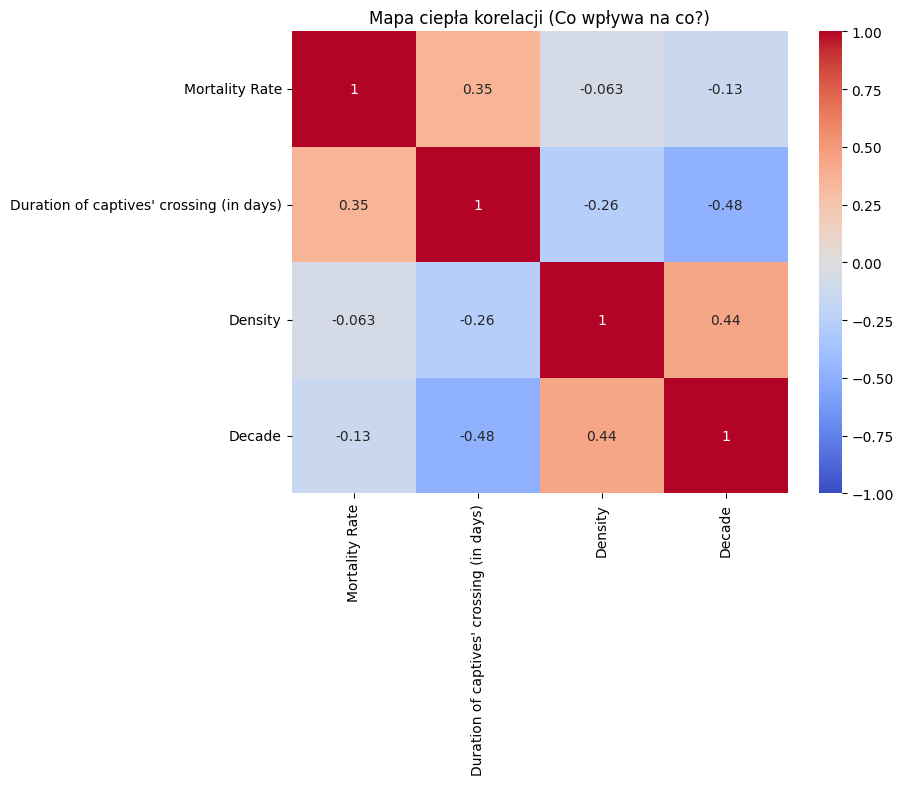

In [ ]:
# KROK NAPRAWCZY: Usuwamy rekordy, gdzie czas trwania jest <= 0 (błędy danych)
df_analysis = df_clean[df_clean["Duration of captives' crossing (in days)"] > 0].copy()

print(f"Liczba wierszy do analizy czasu i śmiertelności: {len(df_analysis)}")

# 1. MACIERZ KORELACJI (Heatmap)
# Sprawdzamy powiązania między: Śmiertelnością, Czasem trwania, Zagęszczeniem i Dekadą
cols_to_check = ['Mortality Rate',
                 "Duration of captives' crossing (in days)",
                 'Density',
                 'Decade']

correlation = df_analysis[cols_to_check].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa ciepła korelacji (Co wpływa na co?)')
plt.show()

Wyres punktowy

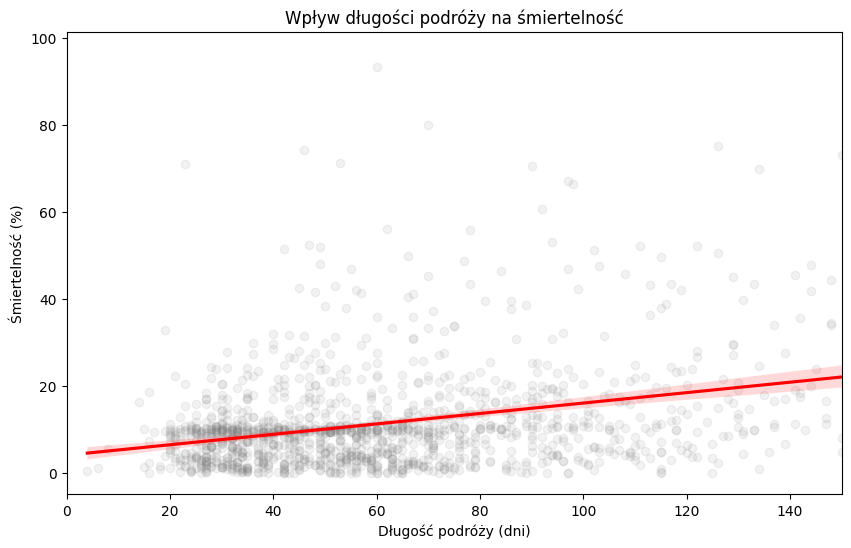

In [ ]:
# 2. WYKRES PUNKTOWY (Scatter Plot) + REGRESJA
# Oś X: Czas podróży, Oś Y: Śmiertelność
plt.figure(figsize=(10, 6))
sns.regplot(data=df_analysis,
            x="Duration of captives' crossing (in days)",
            y="Mortality Rate",
            scatter_kws={'alpha':0.1, 'color': 'grey'}, # Punkty półprzezroczyste
            line_kws={'color': 'red'}) # Linia trendu na czerwono

plt.title('Wpływ długości podróży na śmiertelność')
plt.xlabel('Długość podróży (dni)')
plt.ylabel('Śmiertelność (%)')
plt.xlim(0, 150) # Ograniczamy widok do 150 dni, żeby pozbyć się ekstremalnych wyjątków i lepiej widzieć trend
plt.show()

##Analiza Wyników

---


**Korelacja 0.35 (Czas a Śmiertelność):**

Wniosek: Ten wynik potwierdza, że im dłużej ludzie przebywali w ładowniach, tym częściej umierali (wyczerpanie, kończące się zapasy wody). To nie był "przypadek".

**Korelacja -0.063 (Zagęszczenie a Śmiertelność):**

To jest najbardziej szokujący wniosek tego badania. Intuicja podpowiada: "ścisk = śmierć". Dane mówią: "niekoniecznie".

Historycy uważają, że głównym zabójcą były epidemie (czerwonka, ospa). Gdy wybuchła epidemia, zabijała tak samo skutecznie na luźnym statku, jak i na zatłoczonym. Mikrobom było wszystko jedno.

##Wizualizacja geoprzestrzenna



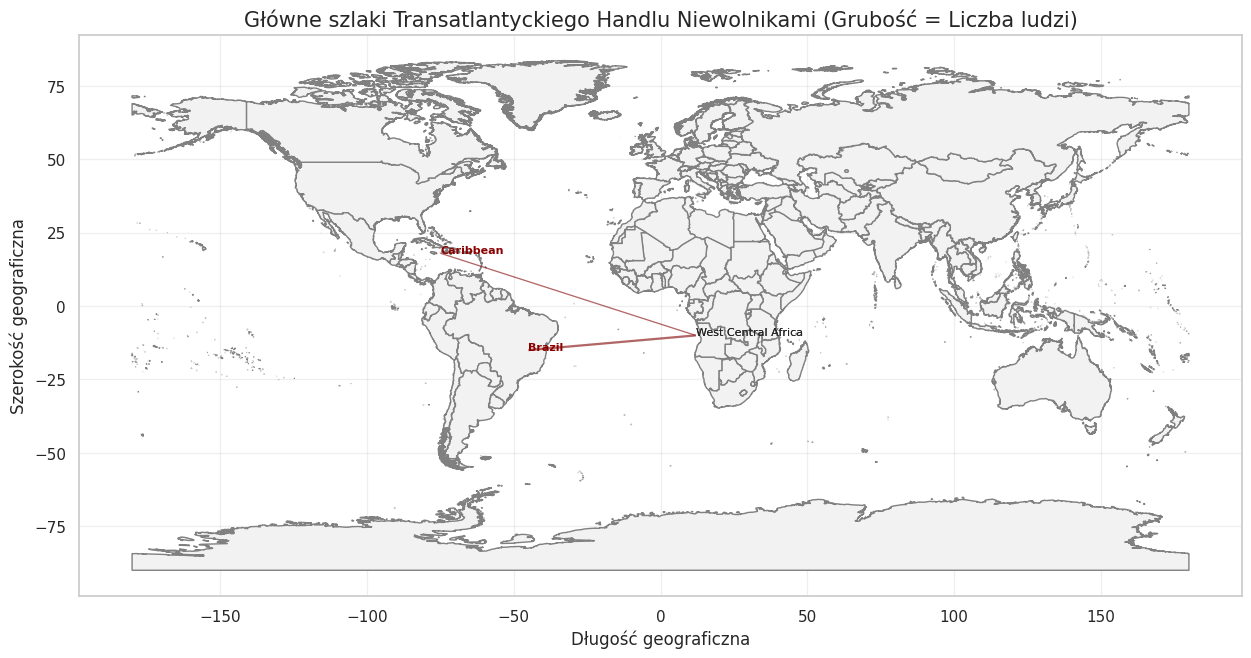

    voyage_itinerary__imp_principal_region_of_slave_purchase__name  \
65          Bight of Biafra and Gulf of Guinea islands               
132                                         Gold Coast               
347                  West Central Africa and St Helena               
350                  West Central Africa and St Helena               
32                                      Bight of Benin               
334                  West Central Africa and St Helena               
165                                       Other Africa               
352                  West Central Africa and St Helena               
181                                       Other Africa               
21                                      Bight of Benin               

    voyage_itinerary__imp_principal_region_slave_dis__name  \
65                                             Jamaica       
132                                            Jamaica       
347                                     Sai

In [ ]:
# 1. PRZYGOTOWANIE DANYCH: Agregacja tras
# Grupujemy po regionie wypłynięcia i regionie docelowym, sumując liczbę ludzi
routes = df_clean.groupby([
    'voyage_itinerary__imp_principal_region_of_slave_purchase__name',
    'voyage_itinerary__imp_principal_region_slave_dis__name'
])['Total embarked (IMP)'].sum().reset_index()

# Sortujemy i bierzemy TOP 10 tras dla czytelności mapy
top_routes = routes.sort_values('Total embarked (IMP)', ascending=False).head(10)

# 2. SŁOWNIK WSPÓŁRZĘDNYCH (Uproszczone środki geograficzne regionów)
# Musimy ręcznie przypisać współrzędne do nazw z kolumn
coords = {
    # Afryka (Początek)
    'West Central Africa': (12.0, -10.0), # Angola/Kongo
    'Bight of Benin': (2.5, 6.5),         # Nigeria/Benin
    'Bight of Biafra': (8.0, 4.0),        # Kamerun/Gwinea
    'Gold Coast': (-1.0, 5.5),            # Ghana
    'Senegambia': (-15.0, 14.0),          # Senegal
    'Southeast Africa': (35.0, -20.0),    # Mozambik
    'Sierra Leone': (-12.0, 8.5),
    'Windward Coast': (-9.0, 6.0),

    # Ameryki (Koniec)
    'Brazil': (-45.0, -15.0),             # Brazylia (główny cel)
    'Caribbean': (-75.0, 18.0),           # Karaiby
    'Mainland North America': (-80.0, 35.0), # USA
    'Spanish American Mainland': (-75.0, 10.0), # Kolumbia/Wenezuela
    'Guianas': (-55.0, 5.0)
}

# Funkcja czyszcząca nazwy regionów, aby pasowały do kluczy w 'coords'
def get_coord_key(region_name):
    if pd.isna(region_name):
        return None
    region_name_str = str(region_name)
    for key in coords:
        if key in region_name_str:
            return key
    # Specjalna obsługa dla 'Spanish American' (skrót od 'Spanish American Mainland')
    if 'Spanish American' in region_name_str and 'Spanish American Mainland' in coords:
        return 'Spanish American Mainland'
    return None

# 3. TWORZENIE GEOMETRII LINII
geometry = []
valid_routes = []

for index, row in top_routes.iterrows():
    # Czyścimy nazwy regionów przed sprawdzeniem w słowniku coords
    origin = get_coord_key(row['voyage_itinerary__imp_principal_region_of_slave_purchase__name'])
    dest = get_coord_key(row['voyage_itinerary__imp_principal_region_slave_dis__name'])

    # Sprawdzamy czy mamy współrzędne w słowniku
    if origin in coords and dest in coords:
        start_pt = Point(coords[origin])
        end_pt = Point(coords[dest])
        line = LineString([start_pt, end_pt])
        geometry.append(line)
        valid_routes.append(row) # Zachowujemy dane o liczbie ludzi

# Konwertujemy listę Series do DataFrame przed utworzeniem GeoDataFrame
df_for_gdf = pd.DataFrame(valid_routes)
# Tworzymy GeoDataFrame
gdf_routes = gpd.GeoDataFrame(df_for_gdf, geometry=geometry)

# 4. RYSOWANIE MAPY
# Pobieramy kontury świata z GeoJSON, aby uniknąć problemów z pobieraniem zip
geojason_url = "https://raw.githubusercontent.com/datasets/geo-countries/main/data/countries.geojson"
world = gpd.read_file(geojson_url)

fig, ax = plt.subplots(figsize=(15, 10))

# Rysujemy kontynenty (jasnoszare)
world.plot(ax=ax, color='#f2f2f2', edgecolor='grey')

# Rysujemy trasy
# Grubość linii zależna od liczby ludzi (dzielimy przez dużą liczbę, żeby skala była OK)
linewidths = gdf_routes['Total embarked (IMP)'] / 100000

gdf_routes.plot(ax=ax,
                color='maroon',
                alpha=0.6,
                linewidth=linewidths)

plt.title('Główne szlaki Transatlantyckiego Handlu Niewolnikami (Grubość = Liczba ludzi)', fontsize=15)
plt.xlabel('Długość geograficzna')
plt.ylabel('Szerokość geograficzna')
plt.grid(True, alpha=0.3)

# Dodajemy etykiety dla TOP 3
for idx, row in gdf_routes.head(3).iterrows():
    origin_coord = coords[get_coord_key(row['voyage_itinerary__imp_principal_region_of_slave_purchase__name'])]
    dest_coord = coords[get_coord_key(row['voyage_itinerary__imp_principal_region_slave_dis__name'])]
    plt.text(origin_coord[0], origin_coord[1], get_coord_key(row['voyage_itinerary__imp_principal_region_of_slave_purchase__name']), fontsize=8)
    plt.text(dest_coord[0], dest_coord[1], get_coord_key(row['voyage_itinerary__imp_principal_region_slave_dis__name']), fontsize=8, color='darkred', fontweight='bold')

plt.show()

# Wyświetlamy tabelę tekstową, żeby zobaczyć liczby
print(top_routes[['voyage_itinerary__imp_principal_region_of_slave_purchase__name', 'voyage_itinerary__imp_principal_region_slave_dis__name', 'Total embarked (IMP)']])

In [ ]:
# Tworzymy kopię, żeby nie psuć danych do mapy
tabela_wynikowa = top_routes.copy()

# 1. Zmiana nazw kolumn na polskie i czytelne
tabela_wynikowa = tabela_wynikowa.rename(columns={
    'voyage_itinerary__imp_principal_region_of_slave_purchase__name': 'Skąd (Region)',
    'voyage_itinerary__imp_principal_region_slave_dis__name': 'Dokąd (Cel)',
    'Total embarked (IMP)': 'Liczba Ludzi'
})

# 2. Resetujemy indeks, żeby mieć ranking 1, 2, 3...
tabela_wynikowa = tabela_wynikowa.reset_index(drop=True)
tabela_wynikowa.index = tabela_wynikowa.index + 1  # Żeby ranking zaczynał się od 1, a nie 0

# 3. Wyświetlamy
print("--- TOP 10 TRAS HANDLU NIEWOLNIKAMI ---")
display(tabela_wynikowa)

--- TOP 10 TRAS HANDLU NIEWOLNIKAMI ---


,Skąd (Region),Dokąd (Cel),Liczba Ludzi
1,Bight of Biafra and Gulf of Guinea islands,Jamaica,261153.0
2,Gold Coast,Jamaica,223812.0
3,West Central Africa and St Helena,Saint-Domingue,204925.0
4,West Central Africa and St Helena,Southeast Brazil,163032.0
5,Bight of Benin,Saint-Domingue,142393.0
6,West Central Africa and St Helena,Jamaica,128520.0
7,Other Africa,Barbados,98832.0
8,West Central Africa and St Helena,Spanish Circum-Caribbean,93797.0
9,Other Africa,Jamaica,90556.0
10,Bight of Benin,Jamaica,82252.0


##Podsumowanie

---

Logistyka Cierpienia: Analiza śmiertelności w Transatlantyckim Handlu Niewolnikami
Cel Projektu: Stworzenie interaktywnego raportu, który przedstawia tragiczną historię transatlantyckiego handlu niewolnikami za pomocą liczb.

1. Czyszczenie i Inżynieria Cech (Feature Engineering):

Usunięcie pustych wierszy: Usunięto rekordy z brakującymi danymi w kluczowych kolumnach, takich jak 'Total embarked (IMP)', zapewniając integralność danych.
Normalizacja roku: Kolumna 'Year arrived with captives' została przekonwertowana na typ numeryczny (int), a wszelkie błędy konwersji zostały usunięte, co umożliwiło analizę czasową.
Obliczenie wskaźników śmiertelności i zagęszczenia:
'Mortality Rate': Obliczono procent śmiertelności, dzieląc liczbę zmarłych ('Total embarked (IMP)' - 'Total disembarked (IMP)') przez liczbę zaokrętowanych. Obsłużono przypadki dzielenia przez zero, przypisując im 0% śmiertelności.
'Density': Stworzono wskaźnik zagęszczenia, dzieląc liczbę zaokrętowanych przez 'Standardized Tonnage (IMP)'. Przypadki dzielenia przez zero (zerowy tonaż) również obsłużono, ustawiając zagęszczenie na 0.
Ograniczenie danych do wiarygodnych: Usunięto rejsy z tonażem <= 0, liczbą zaokrętowanych <= 0 oraz te, w których wskaźnik śmiertelności był poza zakresem 0-100%. Dane dotyczące czasu trwania podróży (Duration) zostały również oczyszczone z wartości równych 0, co interpretowano jako brak danych.

2. Analiza Statystyczna:

Średnia śmiertelność: Po oczyszczeniu danych, średnia śmiertelność wyniosła około 14.45%. Jest to przerażająca statystyka, wskazująca, że statystycznie co siódma osoba umierała podczas transportu.
Korelacja czasu podróży i śmiertelności: Stwierdzono dodatnią korelację (0.35) między długością podróży a śmiertelnością. Im dłużej trwała podróż, tym więcej ludzi umierało, co jest zgodne z intuicją i historycznymi relacjami (wyczerpanie, brak wody).
Korelacja zagęszczenia i śmiertelności: Zaskakująco niska ujemna korelacja (-0.063) między zagęszczeniem a śmiertelnością. Sugeruje to, że zagęszczenie samo w sobie nie było głównym czynnikiem śmiertelności, co potwierdza teorie historyków, że epidemie (czerwonka, ospa) były głównym zabójcą, niezależnie od warunków przeludnienia.

3. Wizualizacja Geoprzestrzenna:

Główne szlaki handlowe: Wygenerowano mapę wizualizującą 10 najbardziej obciążonych tras handlu niewolnikami. Grubość linii na mapie reprezentuje liczbę osób przetransportowanych daną trasą.
Główne regiony: Analiza wykazała, że regiony takie jak Bight of Biafra, Gold Coast i West Central Africa w Afryce były kluczowymi punktami początkowymi, podczas gdy Karaiby (Jamajka, Saint-Domingue) oraz Brazylia (Southeast Brazil) były głównymi celami.

Wnioski Ogólne:

Analiza liczbowa dobitnie pokazuje skalę i brutalność transatlantyckiego handlu niewolnikami. Śmiertelność była integralną częścią tego systemu, a główne szlaki wskazywały na intensywność eksploatacji konkretnych regionów Afryki i Ameryk. Wnioski z korelacji sugerują, że choć czas podróży był istotny, to czynniki takie jak choroby zakaźne miały dominujący wpływ na przerażające wskaźniki śmiertelności, niezależnie od warunków na statku.